In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, root_mean_squared_error,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

In [4]:
sns.set(style="whitegrid")
RANDOM_STATE = 45

In [5]:
df = pd.read_csv('dirty_cafe_sales_processed.csv')
print(df.shape)
df.head()

(10000, 15)


,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
0,TXN_1961373,0.25,0.25,0.125000,2023-09-08,True,False,False,False,False,False,False,True,False,True
1,TXN_4977031,0.75,0.50,0.458333,2023-05-16,False,False,False,False,False,False,False,False,False,False
2,TXN_4271903,0.75,0.00,0.291667,2023-07-19,False,True,False,False,False,False,False,True,False,False
3,TXN_7034554,0.25,1.00,0.375000,2023-04-27,False,False,False,True,False,False,False,False,True,True
4,TXN_3160411,0.25,0.25,0.125000,2023-06-11,True,False,False,False,False,False,False,False,True,False


In [6]:
df_model = df.drop(columns=['Transaction ID']).copy()
print(df_model.shape)
print(df_model.columns.tolist())

(10000, 14)
['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']


In [7]:
TARGET_REG = 'Total Spent'
X_reg = df_model.drop(columns=[TARGET_REG, 'Transaction Date'])
y_reg = df_model[TARGET_REG]

In [8]:
print(X_reg.shape)
print(y_reg.shape)

(10000, 12)
(10000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(8000, 12)
(2000, 12)


In [11]:
dt_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_reg.fit(X_train, y_train)
y_pred_reg = dt_reg.predict(X_test)

In [12]:
rmse = root_mean_squared_error(y_test, y_pred_reg)
mae = mean_absolute_error(y_test, y_pred_reg)
print(rmse)
print(mae)

0.06896988246760488
0.027397751875812146


In [13]:
print(dt_reg.get_depth())
print(dt_reg.get_n_leaves())

15
371


In [14]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, 20]
rmse_list = []

In [15]:
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse_list.append(root_mean_squared_error(y_test, pred))

In [16]:
for d, r in zip(depths, rmse_list):
    print(d, round(r, 4))

1 0.2007
2 0.1464
3 0.1088
4 0.0893
5 0.0717
7 0.0691
10 0.0676
15 0.069
20 0.069


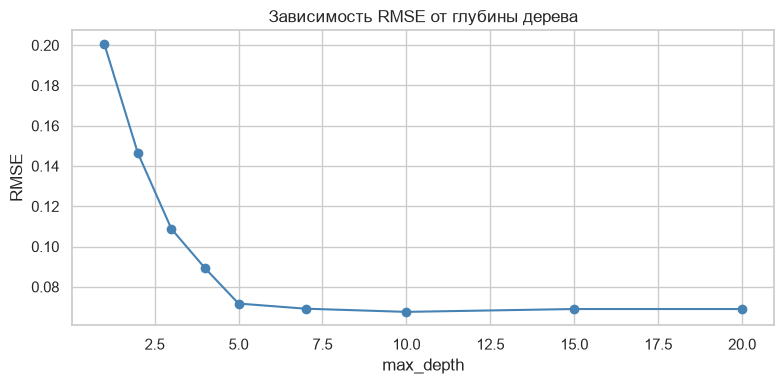

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(depths, rmse_list, marker='o', color='steelblue')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Зависимость RMSE от глубины дерева')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
best_depth = depths[int(np.argmin(rmse_list))]
print(best_depth)

10


In [19]:
dt_reg_best = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE)
dt_reg_best.fit(X_train, y_train)
y_pred_best = dt_reg_best.predict(X_test)

In [20]:
print(root_mean_squared_error(y_test, y_pred_best))
print(mean_absolute_error(y_test, y_pred_best))

0.06755267186072295
0.02643387122369625


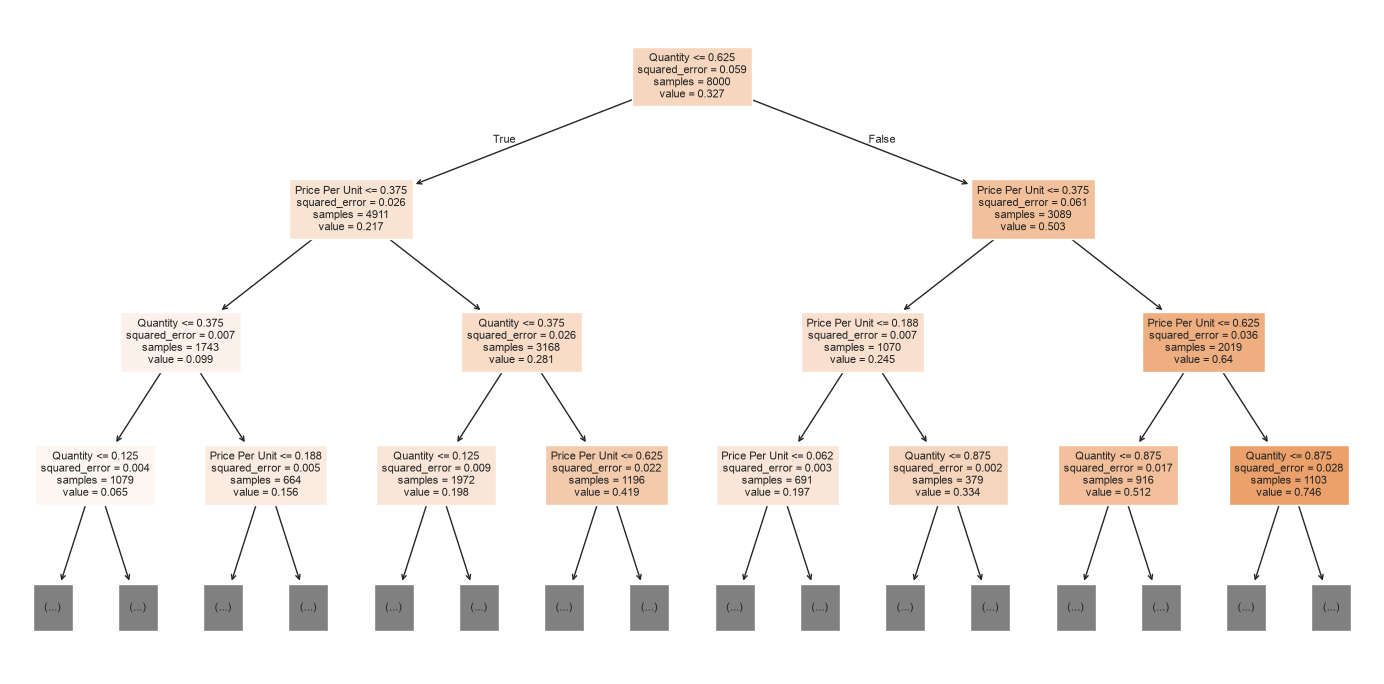

In [21]:
plt.figure(figsize=(14, 7))
plot_tree(dt_reg_best, max_depth=3, filled=True,
          feature_names=X_train.columns, fontsize=8)
plt.tight_layout()
plt.show()

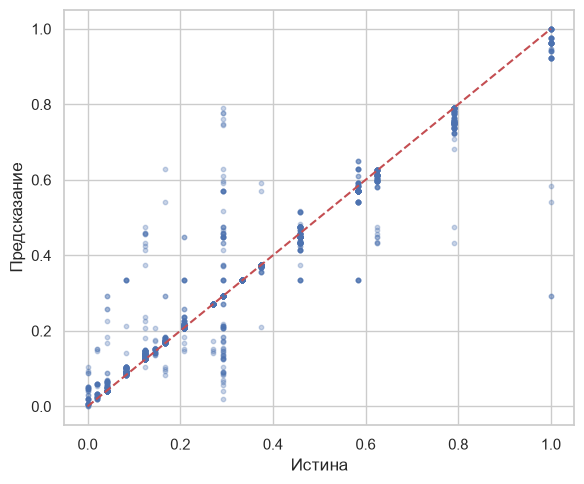

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Истина')
plt.ylabel('Предсказание')
plt.tight_layout()
plt.show()

In [23]:
item_cols = [c for c in df_model.columns if c.startswith('Item_')]
print(item_cols)

['Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea']


In [24]:
df_model['Item_Label'] = df_model[item_cols].idxmax(axis=1).str.replace('Item_', '')

In [25]:
print(df_model['Item_Label'].value_counts())

Item_Label
Coffee      2304
Juice       2140
Salad       1148
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


In [26]:
TARGET_CLF = 'Item_Label'
X_clf = df_model.drop(columns=[TARGET_CLF, 'Transaction Date', 'Total Spent'] + item_cols)
y_clf = df_model[TARGET_CLF]

In [27]:
print(X_clf.shape)
print(X_clf.columns.tolist())
print(sorted(y_clf.unique()))

(10000, 5)
['Quantity', 'Price Per Unit', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']
['Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea']


In [28]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_clf
)

In [29]:
print(X_train_c.shape)
print(X_test_c.shape)

(8000, 5)
(2000, 5)


In [30]:
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_clf.fit(X_train_c, y_train_c)
y_pred_c = dt_clf.predict(X_test_c)

In [31]:
print(accuracy_score(y_test_c, y_pred_c))
print(dt_clf.get_depth())
print(dt_clf.get_n_leaves())

0.6905
10
177


In [32]:
depths_clf = [2, 3, 4, 5, 7, 10, 15]
acc_list = []

In [33]:
for d in depths_clf:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    acc_list.append(accuracy_score(y_test_c, pred))

In [34]:
for d, a in zip(depths_clf, acc_list):
    print(d, round(a, 4))

2 0.5495
3 0.6785
4 0.691
5 0.6915
7 0.693
10 0.6905
15 0.6905


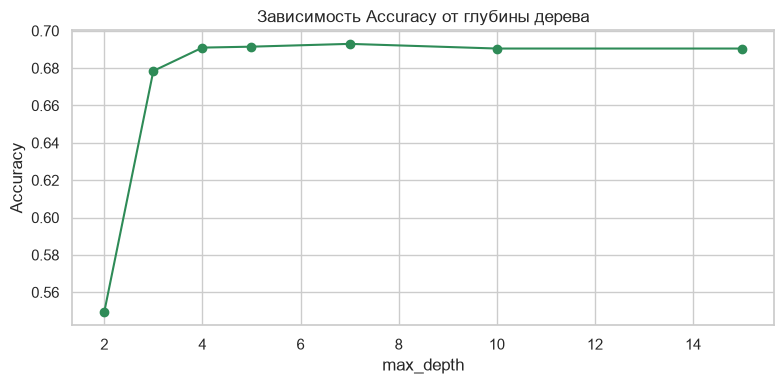

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(depths_clf, acc_list, marker='o', color='seagreen')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от глубины дерева')
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
best_depth_clf = depths_clf[int(np.argmax(acc_list))]
print(best_depth_clf)

7


In [37]:
dt_clf_best = DecisionTreeClassifier(max_depth=best_depth_clf, random_state=RANDOM_STATE)
dt_clf_best.fit(X_train_c, y_train_c)
y_pred_best_c = dt_clf_best.predict(X_test_c)

In [38]:
print(accuracy_score(y_test_c, y_pred_best_c))
print(classification_report(y_test_c, y_pred_best_c, zero_division=0))

0.693
              precision    recall  f1-score   support

      Coffee       0.79      0.58      0.67       461
      Cookie       0.89      0.94      0.92       218
       Juice       0.51      0.61      0.55       428
       Salad       0.88      0.93      0.90       230
    Sandwich       0.52      0.64      0.57       226
    Smoothie       0.50      0.41      0.45       219
         Tea       0.93      0.94      0.94       218

    accuracy                           0.69      2000
   macro avg       0.72      0.72      0.71      2000
weighted avg       0.70      0.69      0.69      2000



In [39]:
cm = confusion_matrix(y_test_c, y_pred_best_c, labels=dt_clf_best.classes_)

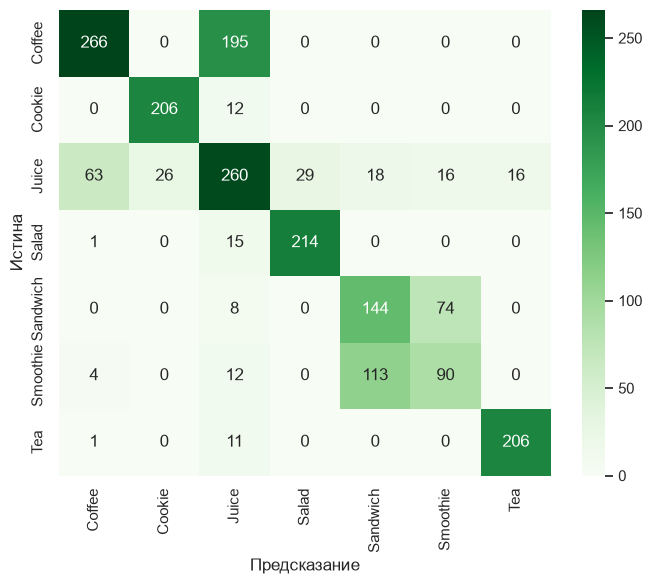

In [40]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=dt_clf_best.classes_,
            yticklabels=dt_clf_best.classes_)
plt.ylabel('Истина')
plt.xlabel('Предсказание')
plt.tight_layout()
plt.show()

In [41]:
classes = sorted(y_clf.unique())
y_test_bin = label_binarize(y_test_c, classes=classes)
y_score = dt_clf_best.predict_proba(X_test_c)

In [42]:
print(classes)
print(y_test_bin.shape)
print(y_score.shape)
print(dt_clf_best.classes_)

['Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea']
(2000, 7)
(2000, 7)
['Coffee' 'Cookie' 'Juice' 'Salad' 'Sandwich' 'Smoothie' 'Tea']


In [43]:
fpr, tpr, roc_auc = {}, {}, {}

In [44]:
for i, cls in enumerate(dt_clf_best.classes_):
    fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

In [45]:
for cls in classes:
    print(cls, round(roc_auc[cls], 4))

Coffee 0.9332
Cookie 0.9813
Juice 0.7556
Salad 0.9784
Sandwich 0.9317
Smoothie 0.9156
Tea 0.982


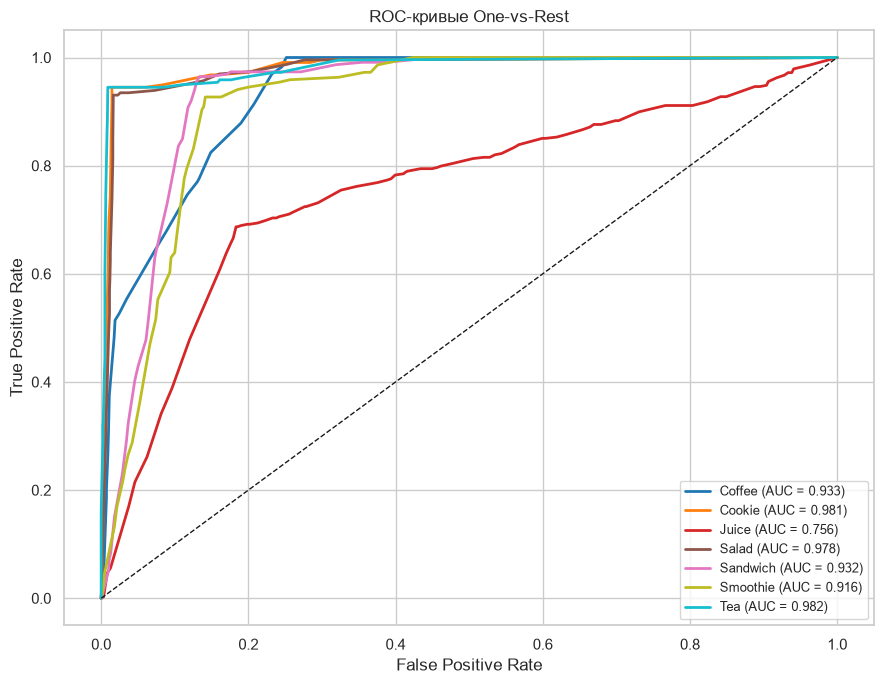

In [46]:
plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for cls, color in zip(classes, colors):
    plt.plot(fpr[cls], tpr[cls], color=color, lw=2,
             label=f'{cls} (AUC = {roc_auc[cls]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые One-vs-Rest')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
roc_auc_macro = np.mean(list(roc_auc.values()))

In [48]:
print(roc_auc_micro)
print(roc_auc_macro)

0.9513107083333334
0.9254173334877999


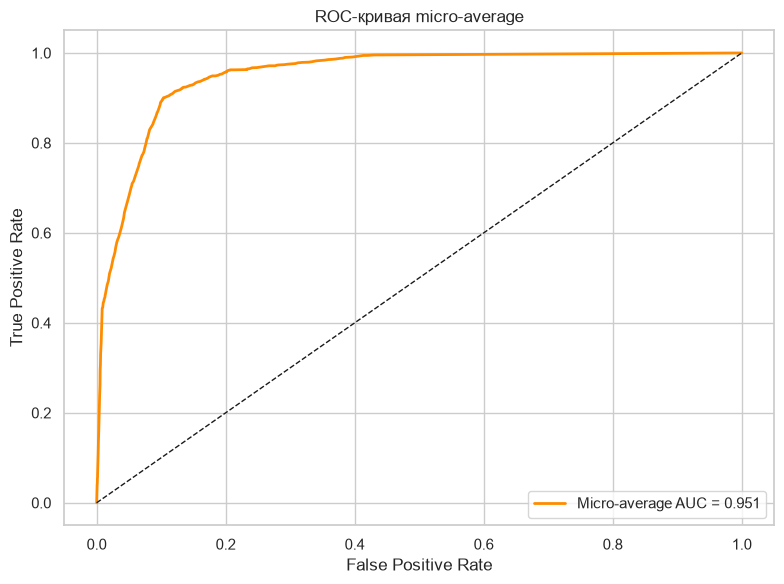

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_micro, tpr_micro, color='darkorange', lw=2,
         label=f'Micro-average AUC = {roc_auc_micro:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая micro-average')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
reg_results = pd.DataFrame({
    'Model': ['DT без ограничений', f'DT max_depth={best_depth}'],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred_reg),
        root_mean_squared_error(y_test, y_pred_best),
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_reg),
        mean_absolute_error(y_test, y_pred_best),
    ]
})
reg_results

,Model,RMSE,MAE
0,DT без ограничений,0.068970,0.027398
1,DT max_depth=10,0.067553,0.026434


In [51]:
reg_results.to_csv('lab3_regression_results.csv', index=False)

In [52]:
with open('lab3_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write("КЛАССИФИКАЦИЯ Item_Label\n")
    f.write(f"Глубина: {best_depth_clf}\n")
    f.write(f"Accuracy: {accuracy_score(y_test_c, y_pred_best_c):.4f}\n\n")
    f.write(classification_report(y_test_c, y_pred_best_c, zero_division=0))
    f.write("\nROC-AUC\n")
    for cls in classes:
        f.write(f"{cls:12s} AUC = {roc_auc[cls]:.4f}\n")
    f.write(f"\nMicro AUC: {roc_auc_micro:.4f}\n")
    f.write(f"Macro AUC: {roc_auc_macro:.4f}\n")

In [53]:
import os
for f in sorted(os.listdir()):
    if f.startswith('lab3'):
        print(f)

lab3.ipynb
lab3_classification_report.txt
lab3_regression_results.csv
